# Kunci Jawaban - Linear Regression

- **Dataset:** Bike Sharing Dataset
- **Target:** `cnt`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Bike Sharing menggunakan ID dataset dari UCI.

In [5]:
bike_sharing = fetch_ucirepo(id=275)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [6]:
X_raw = bike_sharing.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [7]:
y_raw = bike_sharing.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [8]:
TARGET_COL = "cnt"

### Tentukan kolom yang tidak digunakan

Simpan kolom tanggal yang tidak dipakai untuk modeling sederhana.

In [9]:
DROP_COLS = ["dteday"]

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df` agar mudah dicek di tahap EDA.

In [10]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [11]:
df.shape

(17379, 14)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **17379 baris** dan **14 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset awal memiliki **13 fitur** dan **1 target**, yaitu `cnt`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [12]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.240,0.288,0.810,0.000,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.220,0.273,0.800,0.000,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.220,0.273,0.800,0.000,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.240,0.288,0.750,0.000,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.240,0.288,0.750,0.000,1


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Tidak sepenuhnya. Kolom `dteday` berisi tanggal, sedangkan kolom lain berupa angka.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Tidak pada notebook ini, karena kolom `dteday` akan dihapus dan kolom kategori numerik sudah berbentuk angka.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Dataset memiliki kolom `int64`, `float64`, dan satu kolom `object` yaitu `dteday`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **17379 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Pada dataset awal, jumlah baris duplikat penuh adalah **0**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Tidak ada duplikat awal yang perlu dihapus, tetapi duplikat akan dicek lagi setelah kolom tanggal dihapus.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [16]:
df.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,2.502,0.503,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,189.463
std,1.107,0.500,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,181.388
min,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,1.000
25%,2.000,0.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,40.000
50%,3.000,1.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,142.000
75%,3.000,1.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,281.000
max,4.000,1.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,977.000


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, `cnt` bisa mencapai ratusan, sedangkan `temp`, `atemp`, `hum`, dan `windspeed` berada pada rentang desimal.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus kolom tanggal

Hapus kolom `dteday` agar modeling tetap sederhana.

In [17]:
df_clean = df.drop(columns=DROP_COLS).copy()

### Hapus baris duplikat

Hapus baris duplikat penuh setelah kolom tanggal dihapus.

In [18]:
df_clean = df_clean.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah cleaning.

In [19]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah cleaning.

In [20]:
df_clean.shape

(17377, 13)

> Berdasarkan output, berapa ukuran dataset setelah cleaning?

Jawaban: Setelah cleaning, dataset memiliki **17377 baris** dan **13 kolom**.

> Berapa jumlah baris dan kolom yang berkurang dari dataset awal?

Jawaban: Jumlah baris berkurang **2 baris** dan jumlah kolom berkurang **1 kolom** karena `dteday` dihapus.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [21]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah bersih dari duplikat penuh dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [22]:
df_clean[TARGET_COL].describe()

count   17377.000
mean      189.484
std       181.388
min         1.000
25%        40.000
50%       142.000
75%       281.000
max       977.000
Name: cnt, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **189.48**, nilai minimum **1**, dan nilai maksimum **977**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Jumlah rental sepeda sangat bervariasi dari sangat rendah sampai sangat tinggi.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

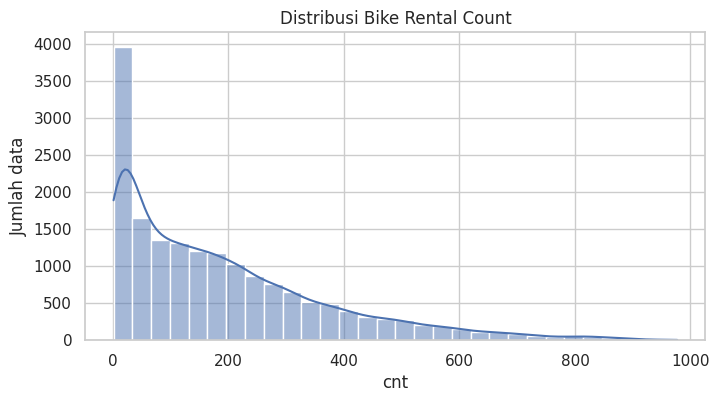

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Bike Rental Count")
plt.xlabel("cnt")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Sebagian besar nilai `cnt` muncul pada rentang rendah sampai menengah.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusi condong ke kanan karena ada nilai rental yang sangat tinggi.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [24]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

temp          0.405
atemp         0.401
hr            0.394
yr            0.251
season        0.178
mnth          0.121
windspeed     0.093
workingday    0.030
weekday       0.027
holiday      -0.031
weathersit   -0.143
hum          -0.323
Name: cnt, dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `temp`, `atemp`, `hr`, dan `yr` memiliki korelasi positif paling terlihat terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `hum`, `weathersit`, dan `holiday` memiliki korelasi negatif terhadap target. Korelasi negatif paling besar terlihat pada `hum`.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

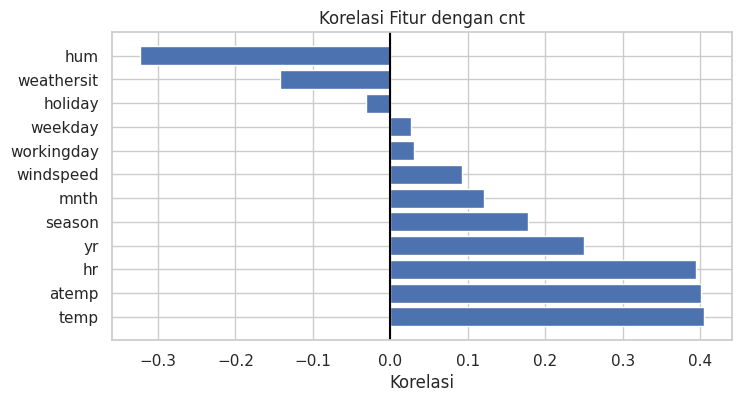

In [25]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan cnt")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi fitur seperti `temp`, `atemp`, `hr`, dan `yr`. Sisi negatif berisi `hum`, `weathersit`, dan `holiday`.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama target, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika target menurun.

### Buat line plot rata-rata target berdasarkan jam

Gunakan line plot rata-rata karena `hr` adalah fitur waktu harian yang berurutan.

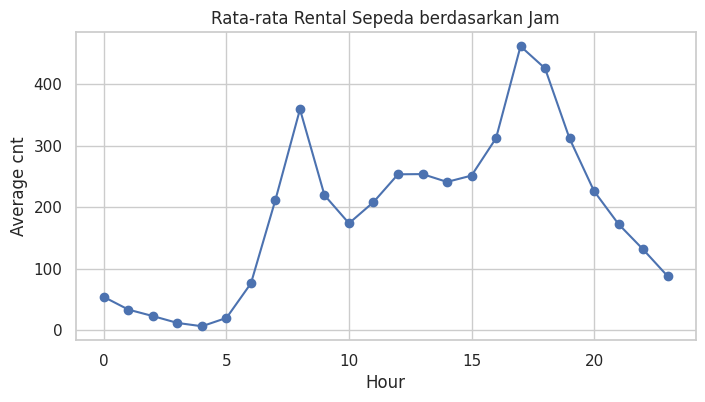

In [26]:
hour_mean = df_clean.groupby("hr")[TARGET_COL].mean()

plt.figure(figsize=(8, 4))
plt.plot(hour_mean.index, hour_mean.values, marker="o")
plt.title("Rata-rata Rental Sepeda berdasarkan Jam")
plt.xlabel("Hour")
plt.ylabel("Average cnt")
plt.show()

> Berdasarkan line plot, bagaimana perubahan rata-rata rental sepeda berdasarkan jam?

Jawaban: Rata-rata rental berubah mengikuti jam dan terlihat lebih tinggi pada jam aktivitas tertentu.

> Mengapa line plot lebih tepat untuk fitur `hr`?

Jawaban: Line plot lebih tepat karena `hr` adalah urutan waktu dalam satu hari, sehingga pola per jam lebih mudah dibaca.

### Buat scatter plot Temperature dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `temp` dengan target.

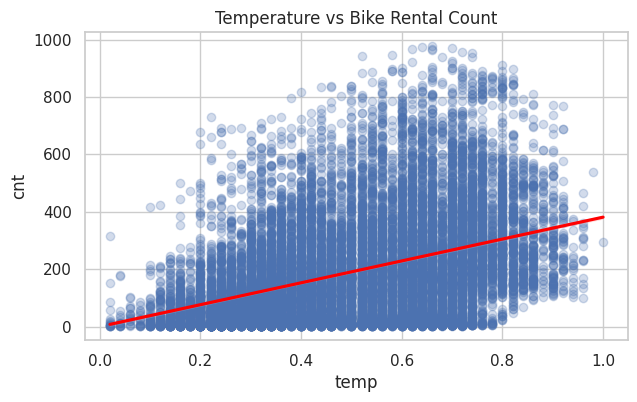

In [27]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="temp",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Temperature vs Bike Rental Count")
plt.xlabel("temp")
plt.ylabel("cnt")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `temp` dengan target?

Jawaban: Saat `temp` lebih tinggi, jumlah rental sepeda cenderung ikut meningkat.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **positif**.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [28]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [29]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [30]:
X.shape

(17377, 12)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **17377 baris** dan **12 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [31]:
y.shape

(17377,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **17377 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **17377**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [34]:
X_train.shape

(13901, 12)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [35]:
X_test.shape

(3476, 12)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **13901 baris**, sedangkan data test memiliki **3476 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **12 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [41]:
model.intercept_

np.float64(190.65815408963383)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **190.66**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,hr,52.779
1,yr,41.096
9,atemp,39.307
0,season,21.703
8,temp,15.988
11,windspeed,4.544
5,weekday,3.470
6,workingday,1.694
2,mnth,1.102
7,weathersit,-1.679


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `hr` sekitar **52.78**, sedangkan koefisien negatif terbesar adalah `hum` sekitar **-39.12**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,333,270.352
1,732,380.287
2,185,264.579
3,526,384.106
4,13,-21.243


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-3, dengan aktual **185** dan prediksi **264.58**. Prediksi paling jauh terlihat pada baris ke-2, dengan aktual **732** dan prediksi **380.29**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Selisih prediksi masih cukup besar pada beberapa baris, sehingga model linear sederhana belum menangkap seluruh pola rental sepeda.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

106.93174872692742

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

103.03464450399508

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **103.03**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **103 rental** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(143.11333876092309)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(136.4532168556541)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **136.45**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.38756600998733004

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.3935051246808361

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.39**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **39%** variasi jumlah rental pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [52]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,106.932,143.113,0.388
1,Test,103.035,136.453,0.394


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih kecil daripada MAE train, RMSE test lebih kecil daripada RMSE train, dan R2 test sedikit lebih besar daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **3.64%** lebih kecil, RMSE test sekitar **4.65%** lebih kecil, dan R2 test sekitar **1.53%** lebih besar dibanding train. Performa train dan test cukup mirip, tetapi nilai R2 masih belum tinggi.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

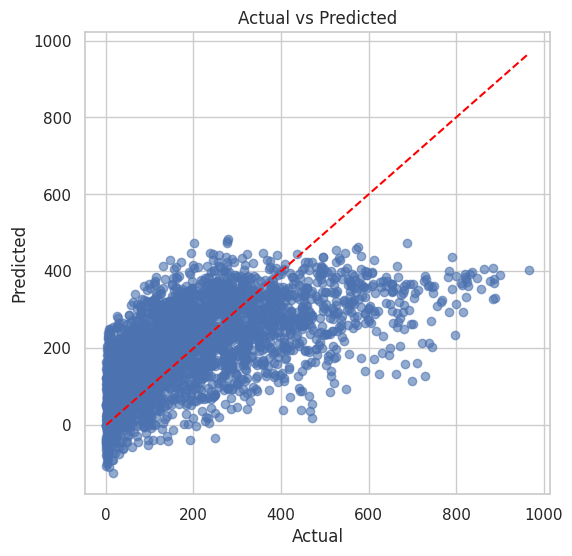

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Bike Sharing Dataset digunakan untuk memprediksi `cnt` atau jumlah rental sepeda berdasarkan informasi waktu, cuaca, dan kondisi hari. Data tidak memiliki missing value dan tidak memiliki duplikat awal, tetapi setelah kolom `dteday` dihapus terdapat baris yang menjadi duplikat dan ikut dihapus. Setelah cleaning, dataset memiliki **17377** baris dan **13** kolom.

Hasil EDA menunjukkan bahwa `temp`, `atemp`, `hr`, dan `yr` memiliki hubungan positif dengan target, sedangkan `hum` dan `weathersit` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **103.03**, RMSE test sekitar **136.45**, dan R2 test sekitar **0.39**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **39%** variasi target pada data test dengan rata-rata error absolut sekitar **103 rental**.